In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
conn = sqlite3.connect("inventory.db")

In [3]:
pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)

,name
0,gold
1,silver
2,oil


In [4]:
gold = pd.read_sql_query("SELECT * FROM gold", conn)
silver = pd.read_sql_query("SELECT * FROM silver", conn)
oil = pd.read_sql_query("SELECT * FROM oil", conn)

In [11]:
gold_copy = gold.copy()
silver_copy = silver.copy()
oil_copy = oil.copy()

## DATA CLEANING

In [12]:
datasets = [gold_copy, silver_copy, oil_copy]

for df in datasets:
    df["Date"] = pd.to_datetime(df["Date"])
    df.set_index("Date", inplace=True)

## CREATE COMBINED DATAFRAME

In [13]:
df = pd.DataFrame({
    "Gold" : gold_copy['Close'],
    "Silver" : silver_copy['Close'],
    "Oil" : oil_copy['Close']
})

In [19]:
df.tail()

,Gold,Silver,Oil
Date,,,
2026-04-23,4705.100098,75.464996,95.849998
2026-04-24,4722.299805,76.383003,94.400002
2026-04-27,4675.399902,75.002998,96.370003
2026-04-28,4591.500000,73.205002,99.930000
2026-04-29,4607.000000,74.199997,99.690002


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6451 entries, 2000-08-23 to 2026-04-29
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gold    6439 non-null   float64
 1   Silver  6441 non-null   float64
 2   Oil     6448 non-null   float64
dtypes: float64(3)
memory usage: 201.6 KB


In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Gold,6432.0,1292.994371,820.643715,255.100006,653.074982,1252.699951,1704.100006,5318.399902
Silver,6434.0,18.697890,11.844957,4.026000,12.262500,17.045000,23.771000,115.080002
Oil,6441.0,64.806732,24.548354,-37.630001,46.540001,63.830002,82.150002,145.289993


In [29]:
df.isnull().sum()

Gold      0
Silver    0
Oil       0
dtype: int64

In [22]:
df[df.isnull().any(axis=1)]

,Gold,Silver,Oil
Date,,,
2000-08-23,NaN,NaN,32.049999
2000-08-24,NaN,NaN,31.629999
2000-08-25,NaN,NaN,32.049999
2000-08-28,NaN,NaN,32.869999
2000-08-29,NaN,NaN,32.720001
2001-09-11,NaN,4.175,NaN
2005-03-30,NaN,NaN,53.990002
2005-04-28,NaN,NaN,51.770000
2005-06-29,NaN,NaN,57.259998


In [30]:
#handling missing value through forward fill to keeps data continuity and dropping remaining null values
#missing data % <<< whole data 1%

df = df.ffill()
df.dropna(inplace=True)

## TREND ANALYSIS

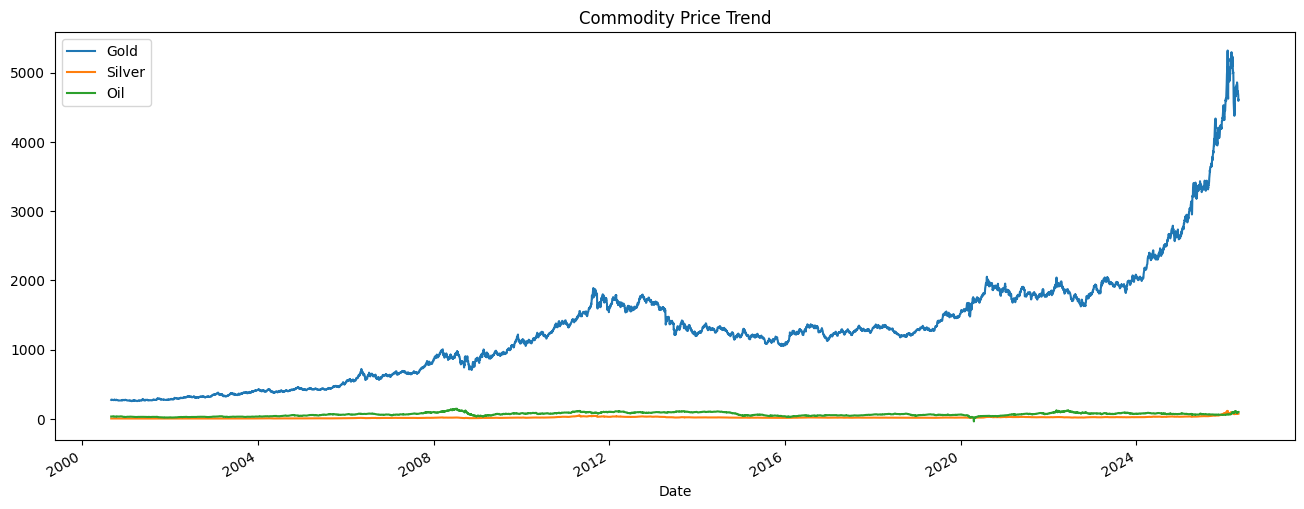

In [32]:
df.plot(figsize=(16,6), title="Commodity Price Trend")
plt.show()

## RETURNS (PROFITABILITY)

### This step converts price data into returns to measure and compare the profitability of each commodity.

In [37]:
returns = df.pct_change()
returns.dropna(inplace=True)
print("Average returns of each assets: \n")
returns.mean()

Average returns of each assets: 



Gold      0.000501
Silver    0.000639
Oil      -0.000066
dtype: float64

## RISK (VOLATILITY)

In [40]:
# Higher = more risky

returns.std()

Gold      0.011195
Silver    0.020712
Oil       0.048888
dtype: float64

## RISK vs RETURN

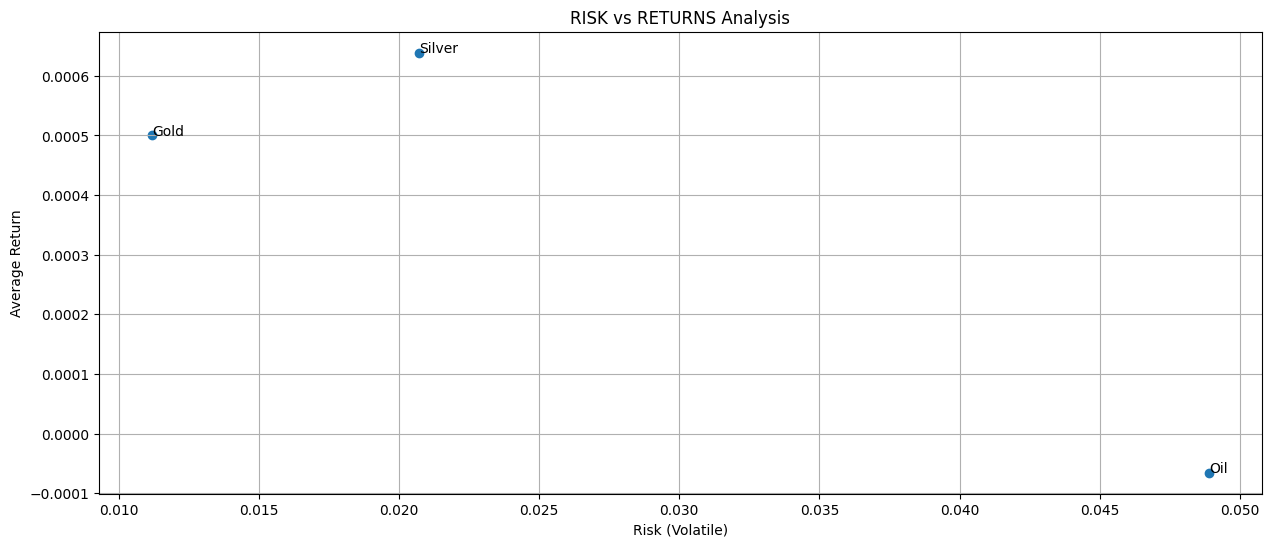

In [43]:
plt.figure(figsize=(15,6))

risk = returns.std()
ret = returns.mean()

plt.scatter(risk, ret)

for i, txt in enumerate(returns.columns):
    plt.annotate(txt, (risk.iloc[i], ret.iloc[i]))
    
plt.xlabel('Risk (Volatile)')
plt.ylabel("Average Return")
plt.title("RISK vs RETURNS Analysis")
plt.grid(True)

plt.show()

### FINAL INSIGHT 

#### “Silver offers the best balance between risk and return, while gold provides stability with lower risk. Oil shows high volatility with poor returns, making it the riskiest asset in the analyzed period.”

## DISTRIBUTION

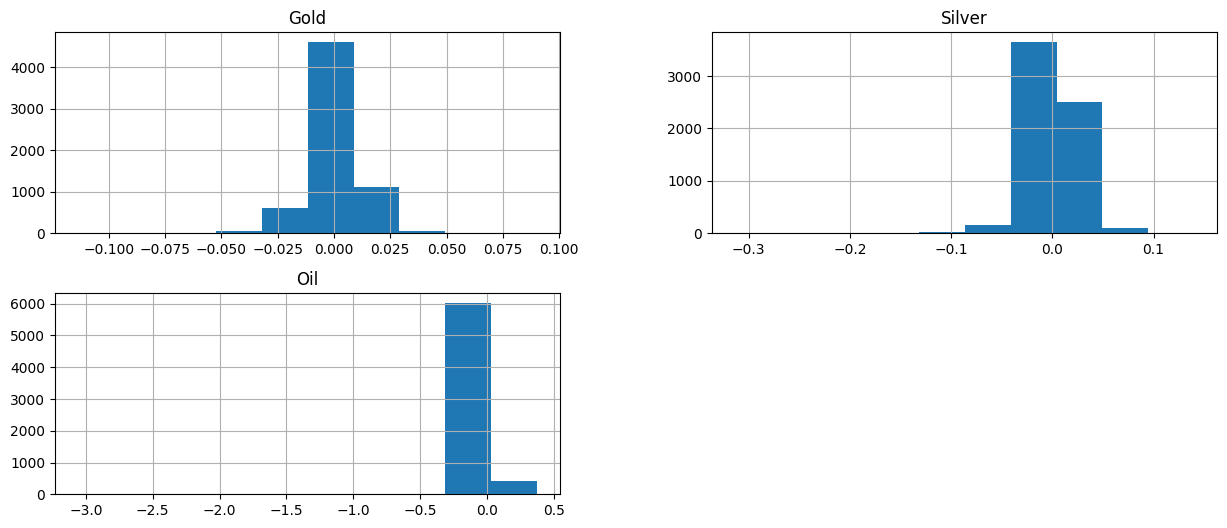

In [44]:
returns.hist(figsize=(15,6))
plt.show()

#### Gold shows a tight return distribution indicating stability, silver shows moderate variability, while oil exhibits extreme volatility with large negative returns.

###

| Asset  | Return       | Risk   |
| ------ | ------------ | ------ |
| Gold   | Medium       | Low    |
| Silver | High         | Medium |
| Oil    | Low/Negative | High   |
###

## CORRELATION

<Axes: >

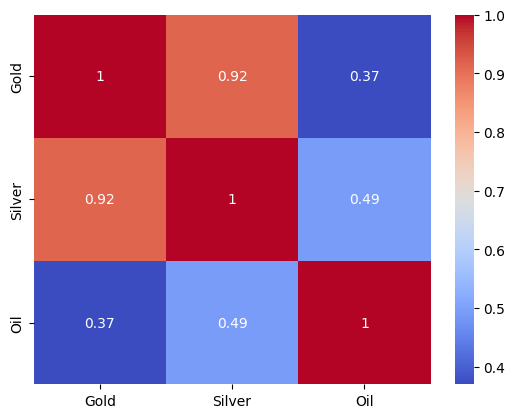

In [46]:
corr = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

#### Gold & Silver → strong relation
#### Oil → different behavior


## ROLLING TREND

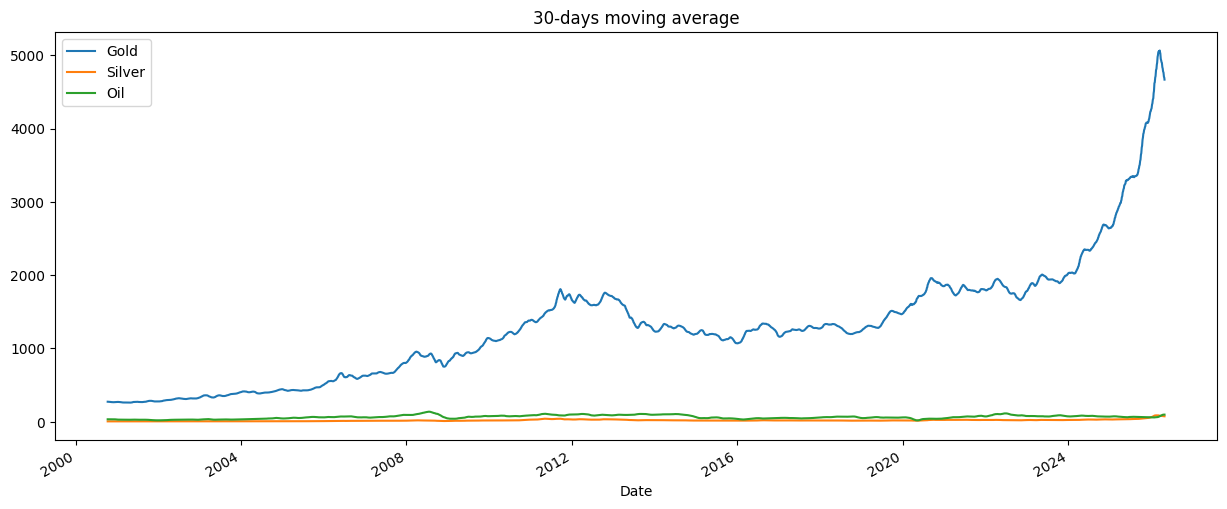

In [47]:
df.rolling(30).mean().plot(figsize=(15,6), title="30-days moving average")
plt.show()

#### Gold shows a consistent long-term upward trend, silver follows a similar but more volatile path, while oil exhibits irregular and cyclical behavior with no stable trend.